# Mem-CVM data analyzer. 

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

from src.file_path import list_files_in_folder, filter_cvm_files, find_seq_file
from src.metadata_utils import extract_CVM_dataframe, extract_read_CVM_dataframes, sort_memcvm_dfs
from src.metadata_utils import build_wide_dataframe_from_list, seq_file_parsing, write_csv_with_metadata
from src.metadata_utils import get_capacitance_near_target_bias
from src.plot import plot_memCVM_overview, plot_memCVM_Vwrite, plot_memCVM_vs_pulse_number, Dashboard_memCVM


# ──────────────────────────────────────────────────────────────────────────────
#   This code is used to plot the data from the FE tester for the CV                       
# ──────────────────────────────────────────────────────────────────────────────


%config InlineBackend.figure_format = 'retina' # For high resolution figures in Jupyter Notebook
#%matplotlib widget

#### Parameters Configuration

Please configure the following parameters in the cell below:

- **<span style="color:green;">Measurement folder path</span>**  
  ⚠️ Do **not** move any files from this folder, especially the sequence file, as the script extracts metadata from it.

- **<span style="color:green;">Output path</span>**  
  Directory where the generated plots and CSV file will be saved. The script generate two subfolder to store the plot and the csv files.

- **<span style="color:green;">Reading voltage</span>**  

####  Reading Voltage Notice

MEM CVM is a specific type of measurement.  
The **ON/OFF ratio** and **memory window** <span style="color:blue;">depend on the **reading BIAS voltage**</span> . Selecting a voltage that is too high or too low will remove the CVM curve from the dataframe that does not have such voltage.

Plus note the following: The **FE-tester** does not use the same measurement points for each CVM, which can result in different **Vmin** and **Vmax** values for each reading pulse.


In [2]:
# ──────────────────────────────────────────────────────────────────────────────
#   Path                       
# ──────────────────────────────────────────────────────────────────────────────

folder_path = r"E:\Polybox\trash\LNO3_weekend"
output_path = r"E:\Polybox\trash\LNO3_weekend"

output_path_csv = os.path.join(output_path, "csv")
output_path_plot = os.path.join(output_path, "plot")

# ──────────────────────────────────────────────────────────────────────────────
#   Parameter                          
# ──────────────────────────────────────────────────────────────────────────────
READING_VOLTAGE = 0.0      # In V, The value must be £inside the window of the Bias reading voltage otherwise you'll get an error !

#### Data extraction

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
#   Extraction of dataframes from the source folder                       
# ──────────────────────────────────────────────────────────────────────────────

CVM_reading_files, CVM_complete_file = filter_cvm_files(list_files_in_folder(folder_path))
Read_CVM_Dataframe: list = []
Vwrite_list: list = []

Main_CVM_Dataframe = extract_CVM_dataframe(CVM_complete_file)
Read_CVM_Dataframe = extract_read_CVM_dataframes(CVM_reading_files)

Read_CVM_Dataframe, Vwrite_list, loop_list = sort_memcvm_dfs(Read_CVM_Dataframe)

#### Dashboard

ON/OFF ratio computed for the last cycle
Dashboard saved to: E:\Polybox\trash\LNO3_weekend\plot\2026-01-16_20260116_LNO3_ID700_Dashboard.png


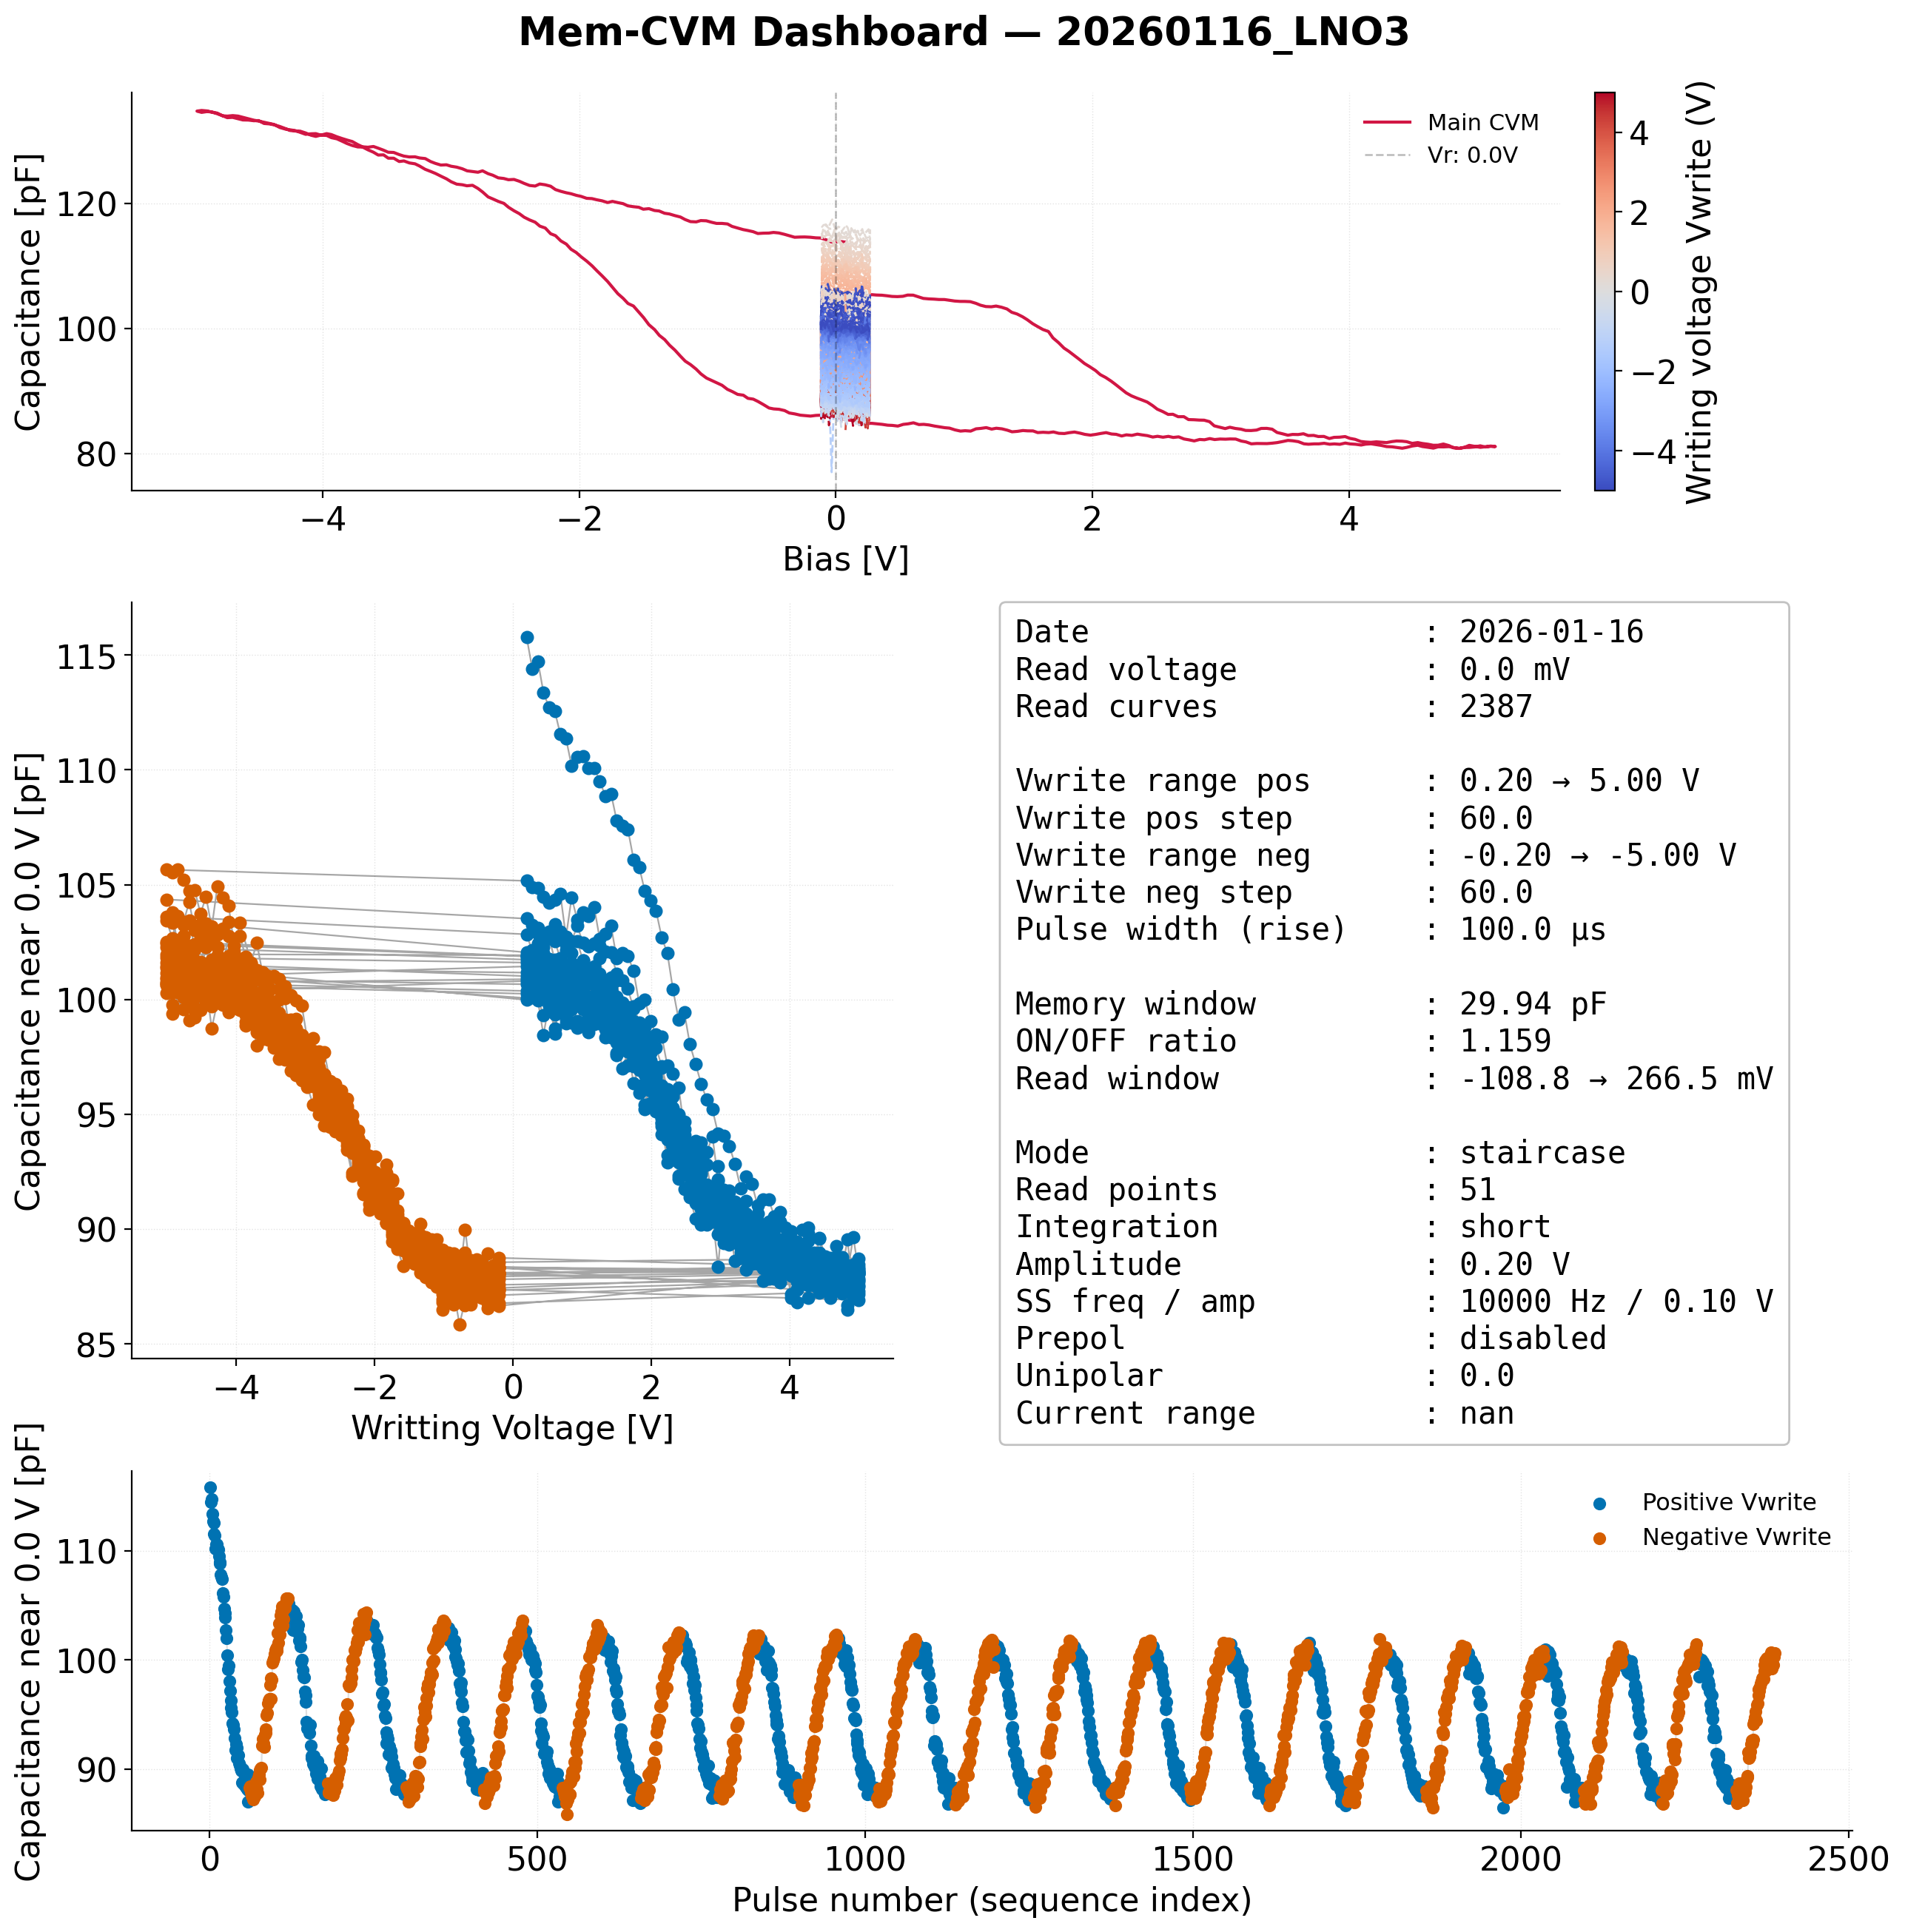

In [5]:
# ──────────────────────────────────────────────────────────────────────────────
#   Plot of the dashboard                       
# ──────────────────────────────────────────────────────────────────────────────
Dashboard_memCVM(Main_CVM_Dataframe=Main_CVM_Dataframe, Read_CVM_Dataframe=Read_CVM_Dataframe, Vwrite_list=Vwrite_list, reading_voltage=READING_VOLTAGE, path_metadata=folder_path, Output_path=output_path_plot)

#### Single plot

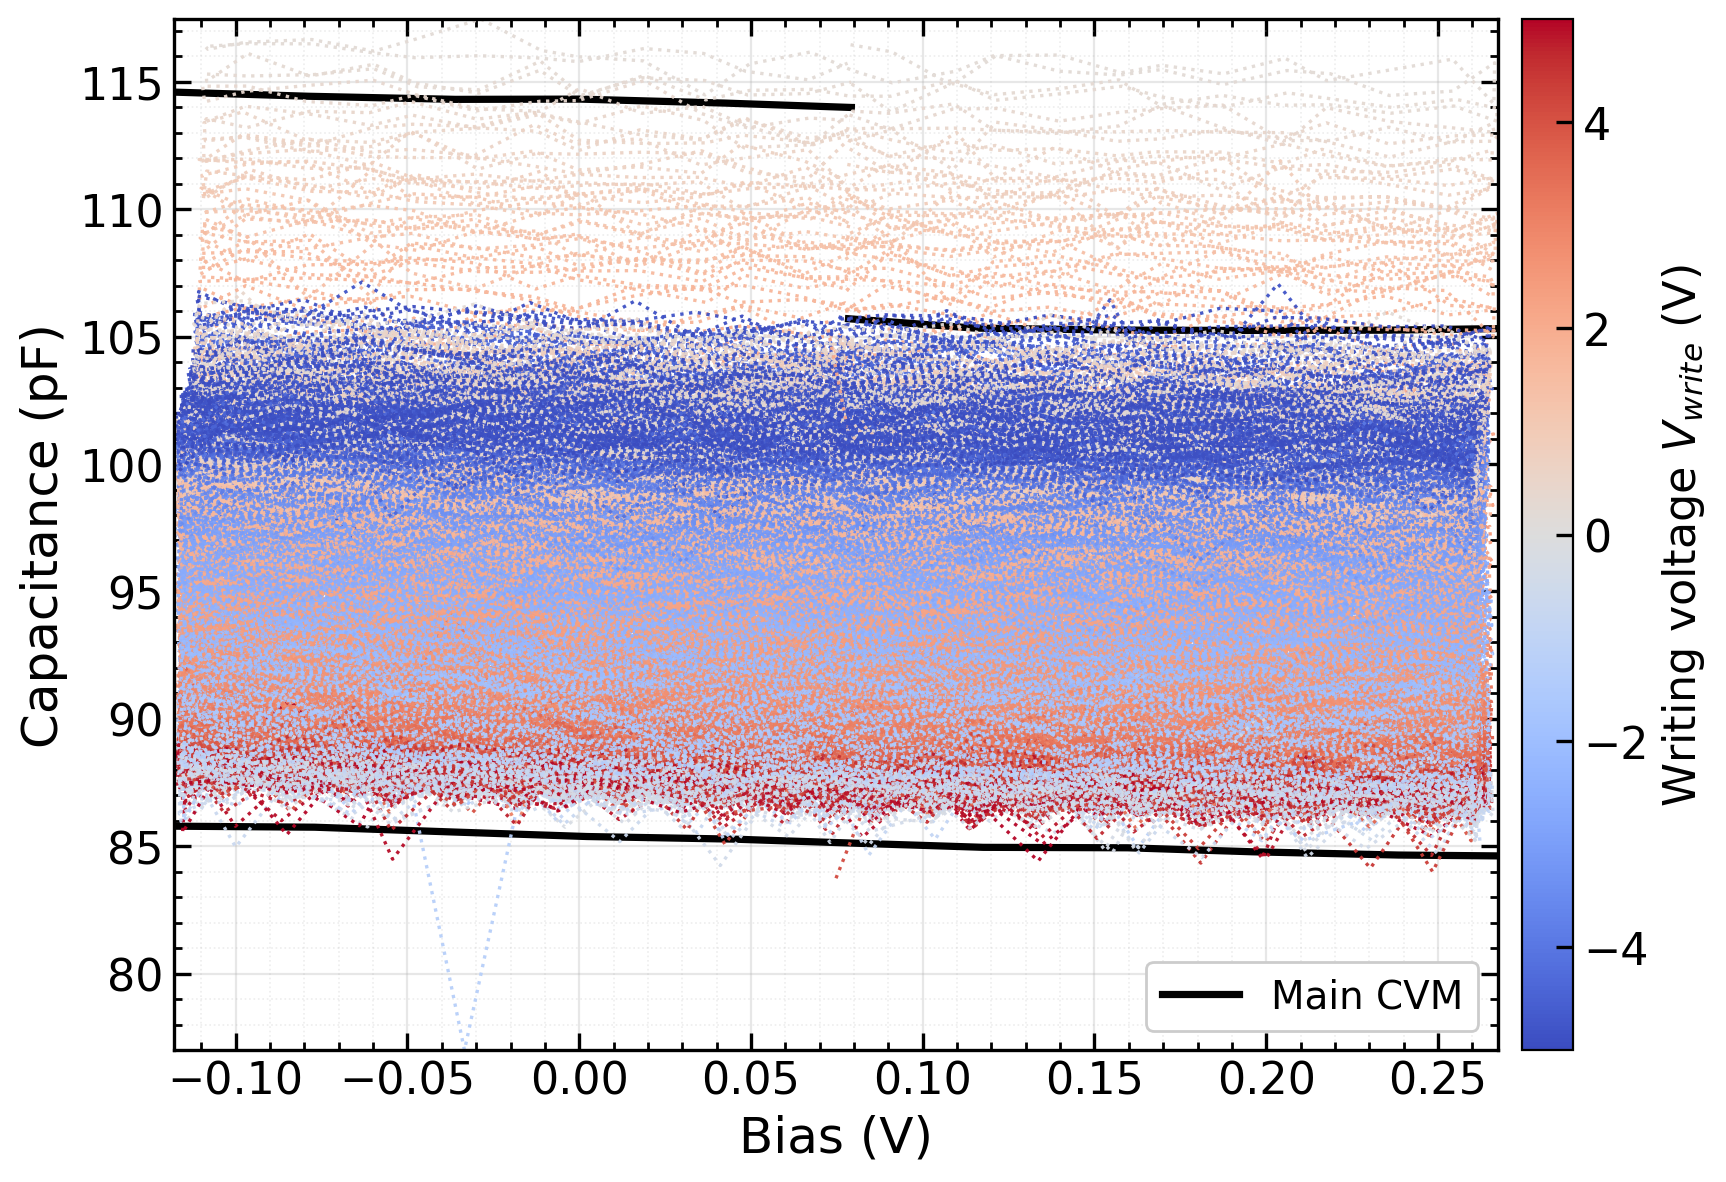

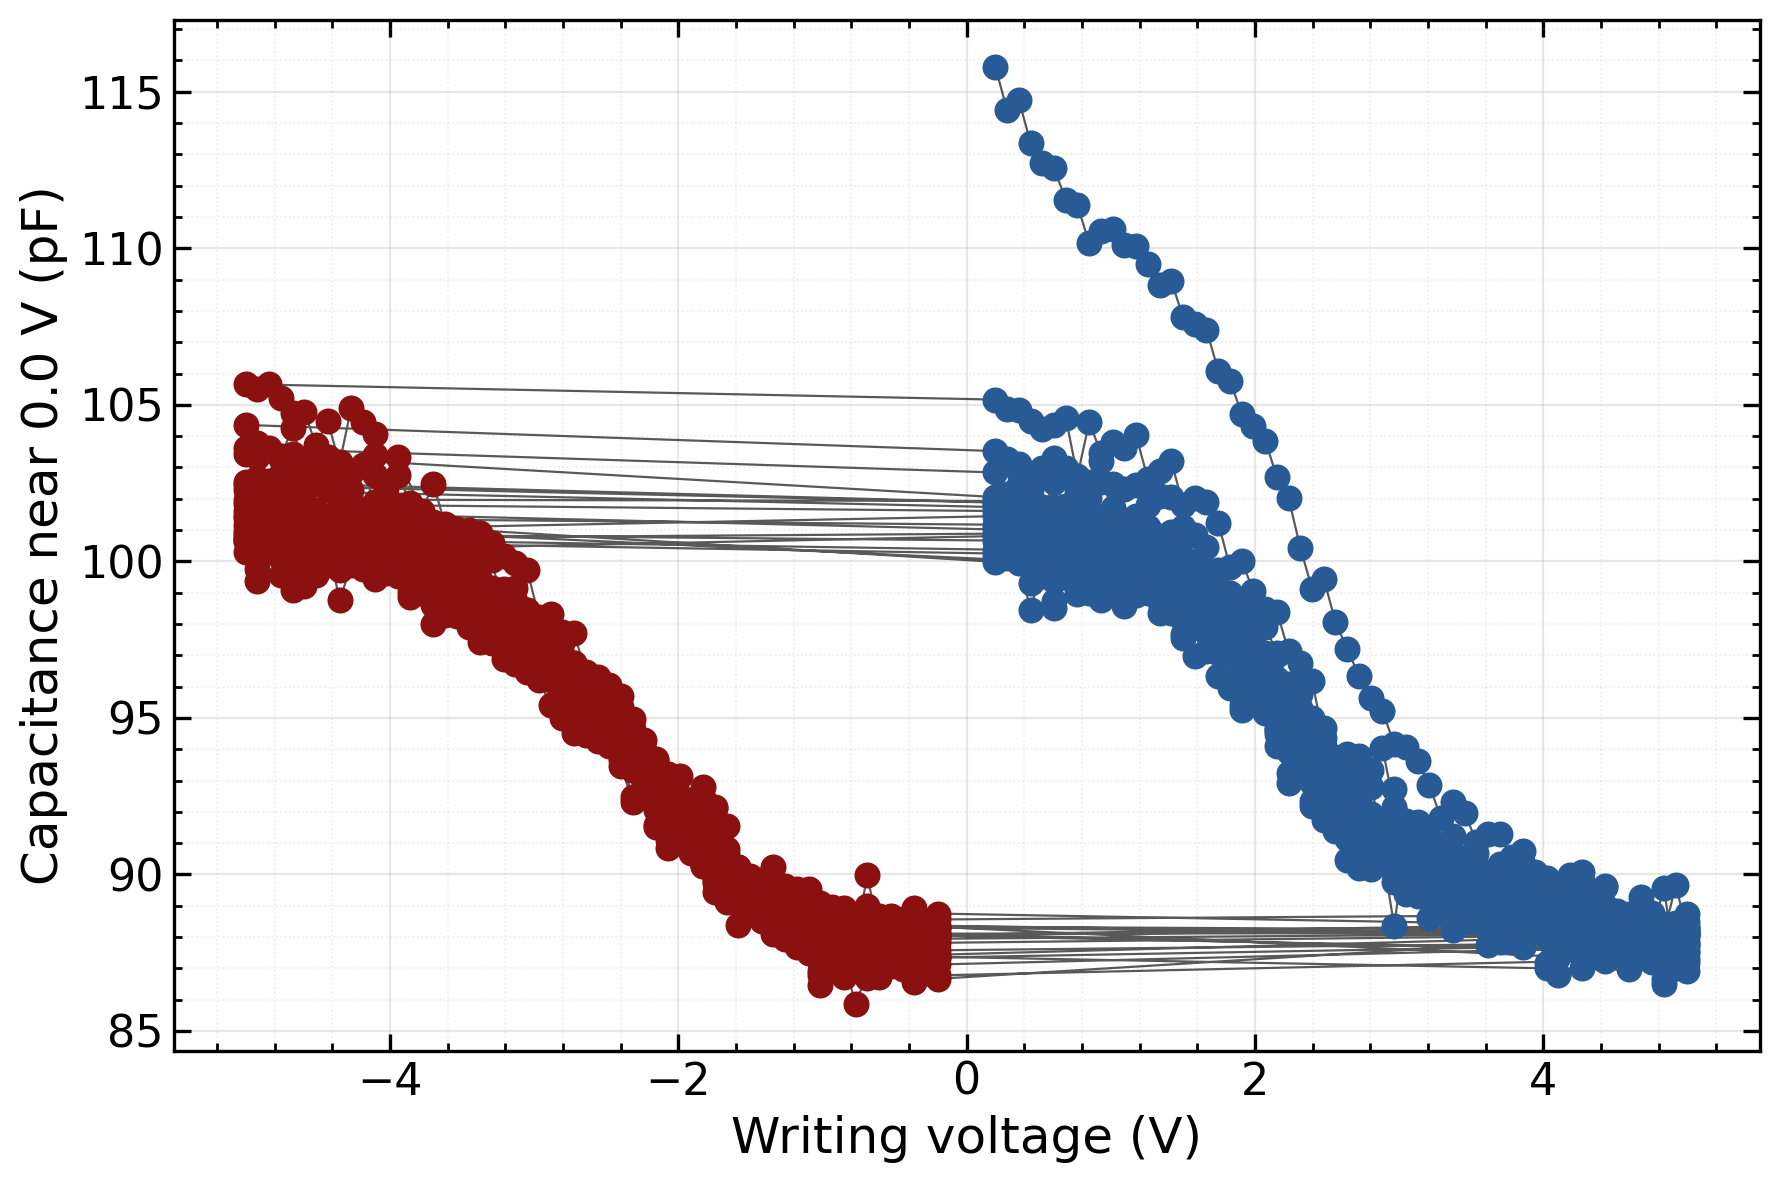

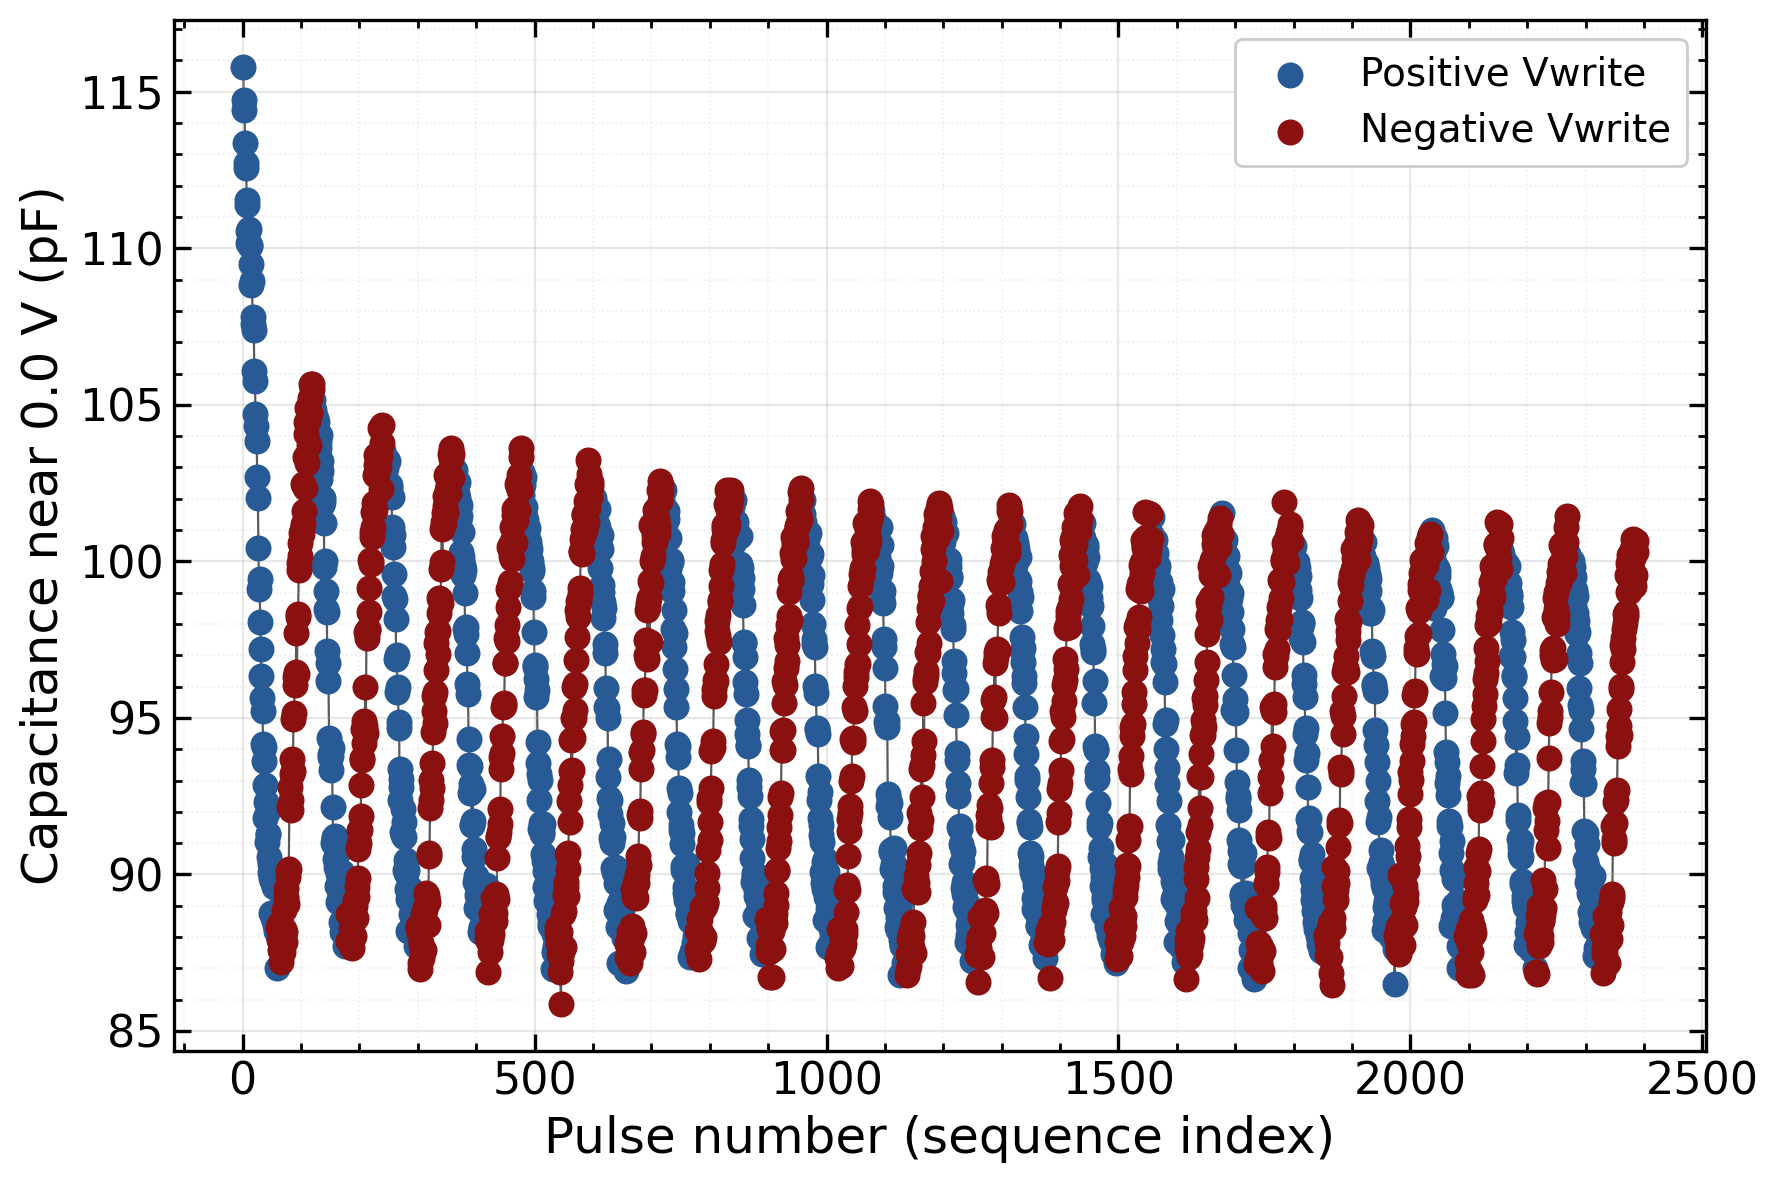

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Pulse number (sequence index)', ylabel='Capacitance near 0.0 V (pF)'>,
 'E:\\Polybox\\trash\\LNO3_weekend\\plot\\2026-01-16_20260116_LNO3_ID700_Cmem_vs_pulse.png')

In [6]:
metadata_df = seq_file_parsing(folder_path)
read_df_wide = build_wide_dataframe_from_list(
    Read_CVM_Dataframe,
    Vwrite_list=Vwrite_list,
    v_col="Bias [V]",
    c_col="C [F]"
)
write_csv_with_metadata(
    Output_path=output_path_csv,
    df_metadata=metadata_df,
    df_data=read_df_wide
)

# ──────────────────────────────────────────────────────────────────────────────
#                           Plot
# ──────────────────────────────────────────────────────────────────────────────

# Vue d'ensemble des mesures mémoire CVM
plot_memCVM_overview(
    Main_CVM_Dataframe=Main_CVM_Dataframe,
    Read_CVM_Dataframe=Read_CVM_Dataframe,
    path_metadata=folder_path,
    Output_dir=output_path_plot,
    reading_voltage=READING_VOLTAGE,
    Vwrite_list=Vwrite_list
)

# Capacité vs tension d'écriture (à tension de lecture fixe)
plot_memCVM_Vwrite(
    Read_CVM_Dataframe=Read_CVM_Dataframe,
    path_metadata=folder_path,
    Output_dir=output_path_plot,
    marker_size=70,
    reading_voltage=READING_VOLTAGE
)

# Évolution de la capacité en fonction du numéro d'impulsion
plot_memCVM_vs_pulse_number(
    Read_CVM_Dataframe=Read_CVM_Dataframe,
    path_metadata=folder_path,
    Output_dir=output_path_plot,
    marker_size=70,
    Vwrite_list=Vwrite_list,
    reading_voltage=READING_VOLTAGE
)

## 🚀 Ideas & Improvements to Explore

#### 🧩 Code Robustness (plot.py)

Add an if condition in plot.py to handle cases where the reading CVM uses a triangular waveform.
Currently, only the staircase waveform is implemented in the script.

#### 📊 Introduce a new plot series showing how:

- the memory window, and
- the ON–OFF ratio
- evolve as a function of the available reading-voltage range.

#### 🔍 Reading-Induced Domain Switching Check

Add a dedicated plot series to detect whether the reading operation itself switches the domain.
Proposed approach:
- Track the minimum voltage of the reading CVM.
- Since the signal ramps up and down, it crosses the same voltage twice.
- Compare the capacitance values at these crossings to detect any discrepancy that could indicate switching.

#### ⚠️ Data Validation & Timeout Handling

Add a verification step and a status string indicating the number of timeouts during the reading CVM.
Rationale:

- Occasionally, a reading pulse fails and produces invalid data that should be ignored.
- Some handling already exists in get_capacitance_from_target (metadata_utils.py):
- If the target voltage is missing from the reading pulse dataframe, the result is set to NaN.

Proposed improvement:
- Use the expected number of datapoints (known from the .seq file metadata).
- Verify this against the dataframe.
- Automatically discard reading pulses that do not meet the expected datapoint count.